- A rewrite to try get the stuff working.

In [4]:
import pandas as pd
from astropy.time import Time
import matplotlib.pyplot as plt
import celerite2
import numpy as np
from celerite2 import terms

# Importing data
data = pd.read_csv(r"./Data/sind_subset1_3.txt", sep='\s',skip_blank_lines=True, header = None)
data.columns = ["JD", "sind"]
time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
data["year"] = time_obj.jyear
data['datetime'] = time_obj.to_datetime(timezone=None)
data = data.set_index('datetime')


# No need to down sample the dataset here. yay!
def split_df(df, train_split=0.7, valid_split=0.2):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()

train_df, valid_df, test_df = split_df(data)
print(train_df.shape, valid_df.shape, test_df.shape)


def plot_predictions(trainingset, validset, results):
    fig,ax = plt.subplots(figsize = (20,5))
    ax.plot(trainingset['year'], trainingset['sind'], color = 'blue', label = 'Training')
    ax.plot(validset['year'], validset['sind'], color = 'orange', label = 'Actual')
    results_time = results.index.to_series().apply(lambda d: d.year + (d.timetuple().tm_yday - 1) / 365.25)
    ax.plot(results_time, results['forecast'], color = 'green', label = 'Predictions')
    ax.fill_between(results_time, results['lower'], results['upper'], color = 'green', alpha = 0.2, label = 'Uncertainties')
    plt.legend()
    plt.show()



train_mean = train_df["sind"].mean()
train_std  = train_df["sind"].std()


(1184, 3) (338, 3) (169, 3)


C:\Users\Joey\AppData\Local\Temp\ipykernel_52544\1935008727.py:9: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(r"./Data/sind_subset1_3.txt", sep='\s',skip_blank_lines=True, header = None)


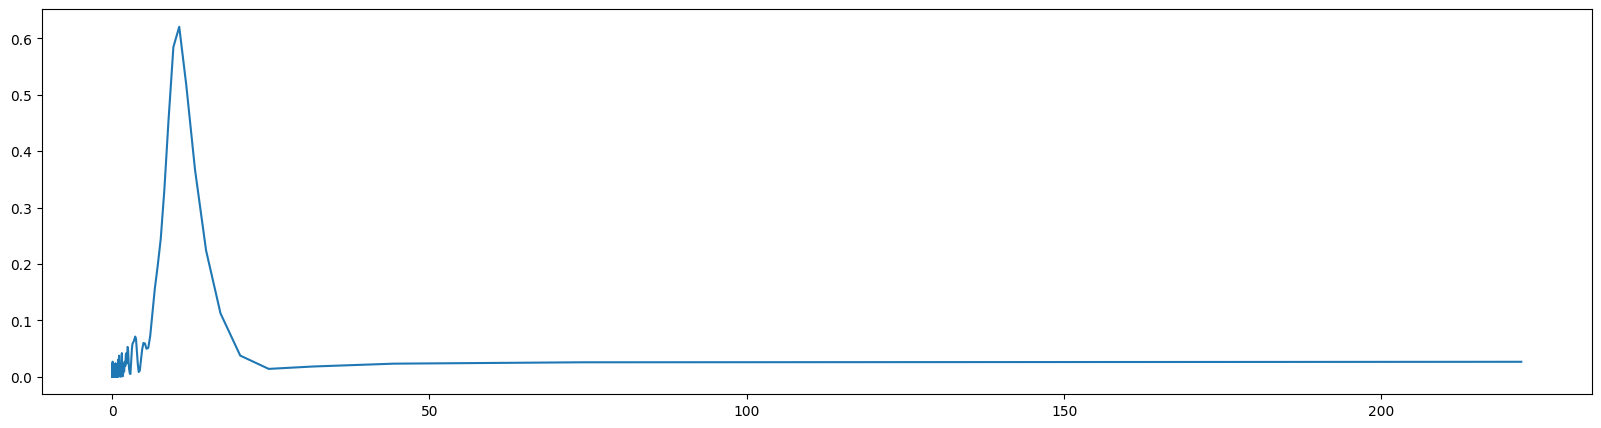

The best period is 10.572472865943448 years


In [5]:
# Lomb scargle 
# Lomb-Scargle finds periodic signals in unevnly sampled time series.
from astropy.timeseries import LombScargle

freq, power = LombScargle(train_df['year'], train_df['sind']).autopower()
# convert freq to period
period = 1/freq


# plot the thing
fig, ax = plt.subplots(1, figsize = (20,5))
ax.plot(period,power)
plt.show()

# print the best period
best_period = period[np.argmax(power)]
print(f"The best period is {best_period} years")


## SHO + ROT kernel


True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
RotationTerm: sigma=0.01623  period=9.500 yr  Q0=0.500  dQ=0.0010  f=0.990
SHOTerm:      sigma=0.01623  period=50.000 yr  Q=0.0100


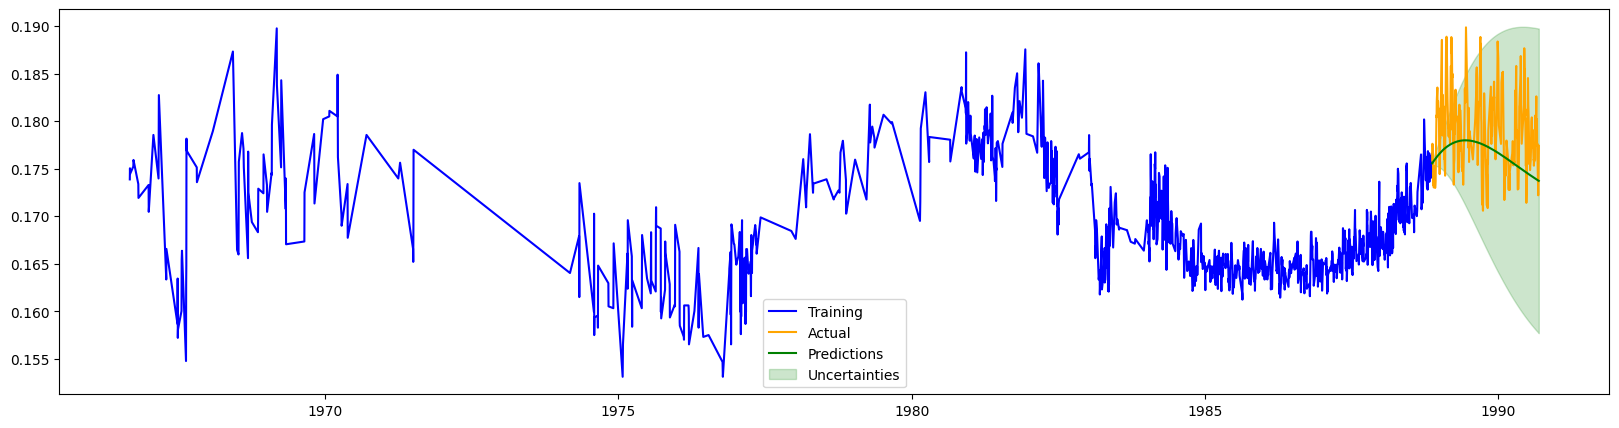

In [7]:
from scipy.optimize import minimize

# It appears that previous attempts were not updating the SHO terms
# Set params has to be different due to the new kernel
def set_params(log_params, gp):
    vals = np.exp(log_params)
    gp.kernel = terms.RotationTerm(sigma=vals[0], period=vals[1], Q0=vals[2], dQ=vals[3], f=vals[4]) # have to replace the kernel otherwise the values don't change
    gp.kernel += terms.SHOTerm(sigma=vals[5], rho=vals[6], Q=vals[7])
    return gp

def NLL(log_params, gp, y):
    gp = set_params(log_params, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)


# quasi-periodic kernel: RotationTerm = two SHO terms
initial_params = {
    "rot_sigma": train_std, # amplitude near observed variability
    "rot_period": 10.57, # solar cycle
    "rot_Q0": 1, # the quality factor of the decaying oscillation; how fast periods can change from one cycle to the next. q < 0.5 is overdamped > is underdamped
                            # choose 1 to be overdamped: plausible that the cycle is decently coherent in the longer term
    "rot_dQ": 0.01, # the difference in quality factors between the two oscillations in the rotation term. The dQ one has double the frequency
                            # this controls the phase coherence; large dq is more asymmetric
                            # we do not expect a strong P/2 signal as the assymetry is not too strong
    "rot_f": 0.1,  # the power fraction from the main term 
    "sho_sigma": 0.005,  # set using total peak-to-peak drift/2
    "sho_rho": 100, # this is the period
    "sho_Q": 0.2 # natural frequency of the oscillator
                        # this lives in the overdamped threshold giving a smooth monotone
}

initial_guess = np.log([
    initial_params["rot_sigma"],
    initial_params["rot_period"],
    initial_params["rot_Q0"],
    initial_params["rot_dQ"],
    initial_params["rot_f"],
    initial_params["sho_sigma"],
    initial_params["sho_rho"],
    initial_params["sho_Q"]
])

sigma_upper = 3 * train_std

bounds = [
    (np.log(0.001), np.log(sigma_upper)),   # rot_sigma: near data std
    (np.log(9.5),   np.log(12.0)),   # rot_period: solar cycle range
    (np.log(0.5),   np.log(10.0)),   # rot_Q0: force underdamped (>0.5)
    (np.log(0.001), np.log(5.0)),    # rot_dQ
    (np.log(0.01),  np.log(0.99)),   # rot_f: fraction in (0,1)
    (np.log(0.001), np.log(sigma_upper)),   # sho_sigma
    (np.log(50.0),  np.log(500.0)),  # sho_rho: long-period trend >> 11 yr
    (np.log(0.01),  np.log(0.49)),   # sho_Q: force overdamped (<0.5)
]


# Adding SHOTerm to the kernel
kernel = terms.RotationTerm( # Asymmetric decaying oscillation in lag-space
    sigma=initial_params['rot_sigma'],
    period=initial_params['rot_period'], 
    Q0=initial_params['rot_Q0'], 
    dQ=initial_params['rot_dQ'], 
    f=initial_params['rot_f'])
kernel += terms.SHOTerm( # This looks like a decaying oscillation
                        sigma=initial_params['sho_sigma'],
                        Q=initial_params['sho_Q'], 
                        rho=initial_params['sho_rho']
)
gp = celerite2.GaussianProcess(kernel, mean=train_mean)
gp.compute(train_df['year'], yerr=1e-3)

gp_res = minimize(NLL, initial_guess, args=(gp, train_df["sind"].to_numpy()), method="L-BFGS-B", bounds=bounds)
gp = set_params(gp_res.x, gp)
gp.recompute()

best = np.exp(gp_res.x)
print(gp_res.success, gp_res.message)
print(f"RotationTerm: sigma={best[0]:.5f}  period={best[1]:.3f} yr  Q0={best[2]:.3f}  dQ={best[3]:.4f}  f={best[4]:.3f}")
print(f"SHOTerm:      sigma={best[5]:.5f}  period={best[6]:.3f} yr  Q={best[7]:.4f}")

# now predict
t_pred = valid_df['year']
mu_lt, cov_lt = gp.predict(train_df['sind'], t = t_pred, return_var = True) # lt indicates long term component from SHOTerm
sigma_lt = np.sqrt(cov_lt)

# plot the lt results

results_lt = pd.DataFrame({
    'forecast' : mu_lt,
    'lower'    : mu_lt - sigma_lt,
    'upper'    : mu_lt + sigma_lt,
}, index=valid_df.index)

plot_predictions(
    trainingset=train_df,
    validset=valid_df,
    results=results_lt
                 )



- This has collapsed to the bounds for all the params. Hmm
- Maybe the model is overparameterised for this small amount of data: try just SHO Term and just ROT Term.

## SHO Kernel

True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
SHOTerm:      sigma=0.00523  period=10.666 yr  Q=4.7294


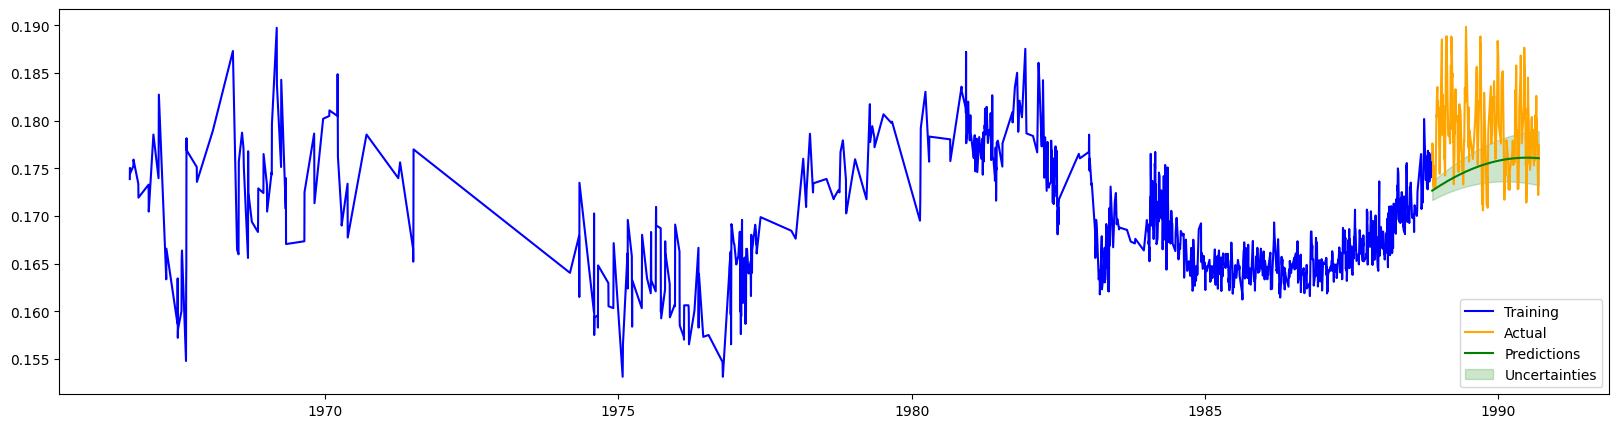

In [16]:
from scipy.optimize import minimize

# It appears that previous attempts were not updating the SHO terms
# Set params has to be different due to the new kernel
def set_params(log_params, gp):
    vals = np.exp(log_params)
    # gp.kernel = terms.RotationTerm(sigma=vals[0], period=vals[1], Q0=vals[2], dQ=vals[3], f=vals[4]) # have to replace the kernel otherwise the values don't change
    gp.kernel = terms.SHOTerm(sigma=vals[0], rho=vals[1], Q=vals[2])
    return gp

def NLL(log_params, gp, y):
    gp = set_params(log_params, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)


# quasi-periodic kernel: RotationTerm = two SHO terms
initial_params = {
    "sho_sigma": 0.003,  # set using total peak-to-peak drift/2
    "sho_rho": 11, # this is the period
    "sho_Q": 0.75 # natural frequency of the oscillator
                        # this lives in the overdamped threshold giving a smooth monotone
}

initial_guess = np.log([
    initial_params["sho_sigma"],
    initial_params["sho_rho"],
    initial_params["sho_Q"]
])

sigma_upper = 5 * train_std

bounds = [
    (np.log(0.001), np.log(sigma_upper)),   # sho_sigma
    (np.log(10.0),  np.log(12.0)),  # sho_rho: long-period trend >> 11 yr
    (np.log(0.5),  np.log(10)),   # sho_Q: force underdamped (>0.5)
]


kernel = terms.SHOTerm( # This looks like a decaying oscillation
                        sigma=initial_params['sho_sigma'],
                        Q=initial_params['sho_Q'], 
                        rho=initial_params['sho_rho']
)
gp = celerite2.GaussianProcess(kernel, mean=train_mean)
gp.compute(train_df['year'], yerr=1e-2)

gp_res = minimize(NLL, initial_guess, args=(gp, train_df["sind"].to_numpy()), method="L-BFGS-B", bounds=bounds)
gp = set_params(gp_res.x, gp)
gp.recompute()

best = np.exp(gp_res.x)
print(gp_res.success, gp_res.message)
# print(f"RotationTerm: sigma={best[0]:.5f}  period={best[1]:.3f} yr  Q0={best[2]:.3f}  dQ={best[3]:.4f}  f={best[4]:.3f}")
print(f"SHOTerm:      sigma={best[0]:.5f}  period={best[1]:.3f} yr  Q={best[2]:.4f}")

# now predict
t_pred = valid_df['year']
mu_lt, cov_lt = gp.predict(train_df['sind'], t = t_pred, return_var = True) # lt indicates long term component from SHOTerm
sigma_lt = np.sqrt(cov_lt)

# plot the lt results

results_lt = pd.DataFrame({
    'forecast' : mu_lt,
    'lower'    : mu_lt - sigma_lt,
    'upper'    : mu_lt + sigma_lt,
}, index=valid_df.index)

plot_predictions(
    trainingset=train_df,
    validset=valid_df,
    results=results_lt
                 )



1) 
    - This gets the period right but still collapses to the bounds for Q and sigma.
    - Are we still underdetermined?
    - The problem seems to improve significantly when I change the yerr. Maybe implement the 2% error thing.


## ROT Kernel

True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
RotationTerm: sigma=0.01623  period=9.500 yr  Q0=0.500  dQ=0.0010  f=0.990


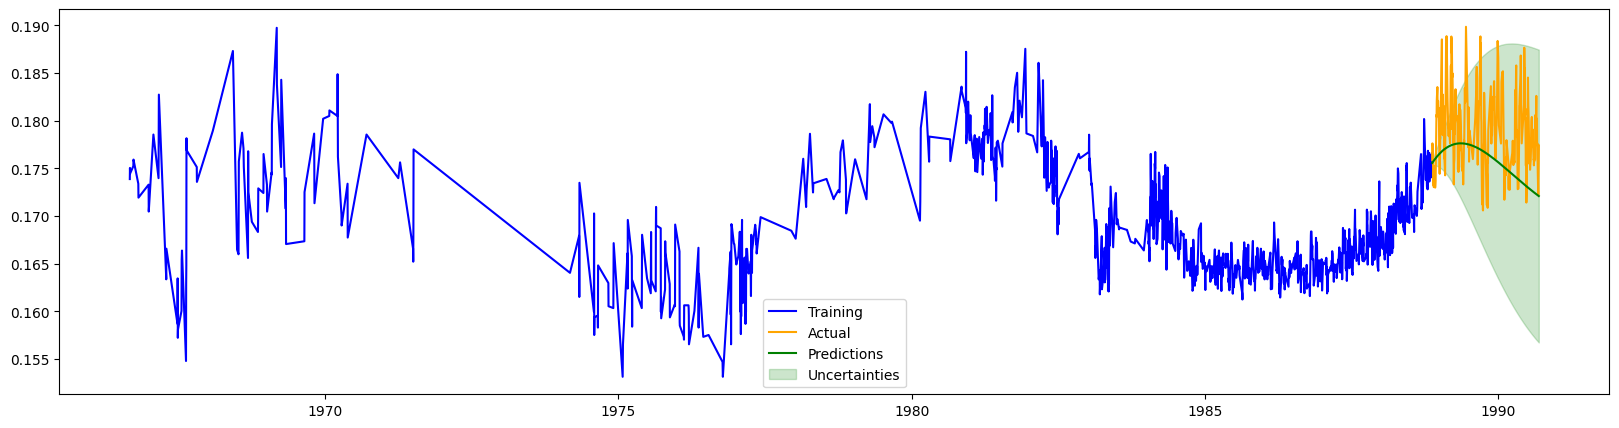

In [13]:
from scipy.optimize import minimize

# It appears that previous attempts were not updating the SHO terms
# Set params has to be different due to the new kernel
def set_params(log_params, gp):
    vals = np.exp(log_params)
    gp.kernel = terms.RotationTerm(sigma=vals[0], period=vals[1], Q0=vals[2], dQ=vals[3], f=vals[4]) # have to replace the kernel otherwise the values don't change
    return gp

def NLL(log_params, gp, y):
    gp = set_params(log_params, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)


# quasi-periodic kernel: RotationTerm = two SHO terms
initial_params = {
    "rot_sigma": train_std, # amplitude near observed variability
    "rot_period": 10.57, # solar cycle
    "rot_Q0": 1, # the quality factor of the decaying oscillation; how fast periods can change from one cycle to the next. q < 0.5 is overdamped > is underdamped
                            # choose 1 to be overdamped: plausible that the cycle is decently coherent in the longer term
    "rot_dQ": 0.01, # the difference in quality factors between the two oscillations in the rotation term. The dQ one has double the frequency
                            # this controls the phase coherence; large dq is more asymmetric
                            # we do not expect a strong P/2 signal as the assymetry is not too strong
    "rot_f": 0.1,  # the power fraction from the main term 
}

initial_guess = np.log([
    initial_params["rot_sigma"],
    initial_params["rot_period"],
    initial_params["rot_Q0"],
    initial_params["rot_dQ"],
    initial_params["rot_f"],
])

sigma_upper = 3 * train_std

bounds = [
    (np.log(0.001), np.log(sigma_upper)),   # rot_sigma: near data std
    (np.log(9.5),   np.log(12.0)),   # rot_period: solar cycle range
    (np.log(0.5),   np.log(10.0)),   # rot_Q0: force underdamped (>0.5)
    (np.log(0.001), np.log(5.0)),    # rot_dQ
    (np.log(0.01),  np.log(0.99)),   # rot_f: fraction in (0,1)
]


# Adding SHOTerm to the kernel
kernel = terms.RotationTerm( # Asymmetric decaying oscillation in lag-space
    sigma=initial_params['rot_sigma'],
    period=initial_params['rot_period'], 
    Q0=initial_params['rot_Q0'], 
    dQ=initial_params['rot_dQ'], 
    f=initial_params['rot_f'])

gp = celerite2.GaussianProcess(kernel, mean=train_mean)
gp.compute(train_df['year'], yerr=1e-3)

gp_res = minimize(NLL, initial_guess, args=(gp, train_df["sind"].to_numpy()), method="L-BFGS-B", bounds=bounds)
gp = set_params(gp_res.x, gp)
gp.recompute()

best = np.exp(gp_res.x)
print(gp_res.success, gp_res.message)
print(f"RotationTerm: sigma={best[0]:.5f}  period={best[1]:.3f} yr  Q0={best[2]:.3f}  dQ={best[3]:.4f}  f={best[4]:.3f}")

# now predict
t_pred = valid_df['year']
mu_lt, cov_lt = gp.predict(train_df['sind'], t = t_pred, return_var = True) # lt indicates long term component from SHOTerm
sigma_lt = np.sqrt(cov_lt)

# plot the lt results

results_lt = pd.DataFrame({
    'forecast' : mu_lt,
    'lower'    : mu_lt - sigma_lt,
    'upper'    : mu_lt + sigma_lt,
}, index=valid_df.index)

plot_predictions(
    trainingset=train_df,
    validset=valid_df,
    results=results_lt
                 )

